# Travel Insurance
Travel Insurance with the target attribute of: **Claim Status (Yes or No)**

(This notebook aggregates results from other notebooks)

In [1]:
%load_ext kedro.ipython

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from category_encoders.cat_boost import CatBoostEncoder
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

[01/12/25 23:26:23] INFO     Using 'conf\logging.yml' as logging configuration. You can change this ]8;id=888685;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=551938;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             by setting the KEDRO_LOGGING_CONFIG environment variable accordingly.                 

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=925777;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=712397;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=31665;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=293628;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Resolved project path as: d:\UNIWERSYTET WARSZAWSKI\Machine Learning   ]8;id=974507;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=869135;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#178\178]8;;\
                             in Finance\II\Projects\ML_travel_insurance.                                           
                             To set a different path, run '%reload_kedro <project_root>'                           

[01/12/25 23:26:32] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=806277;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=131857;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[01/12/25 23:26:33] INFO     Kedro project ML_travel_insurance                                      ]8;id=633202;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=483518;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=33307;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=354994;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#145\145]8;;\
                             'pipelines'                                                                           

In [2]:
X_train = catalog.load('TI_train')
X_test = catalog.load('TI_test')
y_train = catalog.load('TI_y_train')
y_test = catalog.load('TI_y_test')

y_train = y_train == 'Yes'
y_test = y_test == 'Yes'

                    INFO     Loading data from TI_train (CSVDataset)...                         ]8;id=568715;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=945774;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test (CSVDataset)...                          ]8;id=297851;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=117956;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train (CSVDataset)...                       ]8;id=956070;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=930245;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test (CSVDataset)...                        ]8;id=713588;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=543654;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

### Target Column and Imbalance

Claim column is highly imbalanced, positive claim is rare.

Stratified train-test split has been performed.

In [3]:
y_train_counts = y_train.value_counts()
y_test_counts = y_test.value_counts()

classes_df = pd.DataFrame(
    {
        'claim': [v[0] for v in y_train_counts.index.values],
        'train': y_train_counts,
        'train_%': y_train_counts / y_train.shape[0],
        'test': y_test_counts,
        'test_%': y_test_counts / y_test.shape[0],
    }
).reset_index(drop=True)
classes_df

,claim,train,train_%,test,test_%
0,False,49918,0.985353,12481,0.985394
1,True,742,0.014647,185,0.014606


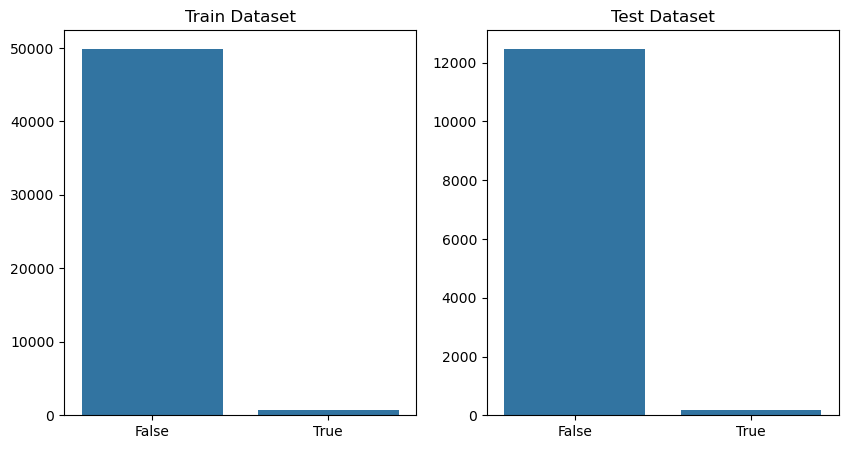

In [4]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].set_title('Train Dataset')
sns.barplot(classes_df, x='claim', y='train', ax=axs[0])
axs[0].set(xlabel=None, ylabel=None)

axs[1].set_title('Test Dataset')
sns.barplot(classes_df, x='claim', y='test', ax=axs[1])
axs[1].set(xlabel=None, ylabel=None)

plt.show()

As the result, we will expect difficulties with fitting models because of large imbalance.

### Features

#### Categorical Features

- agency
- agency_type
- distribution_channel
- product_name
- gender
- destination

For features with large amount of categories, catboost encoding is applied, for others it is one-hot encoding.

In [5]:
X_train.isna().sum()


agency                      0
agency_type                 0
distribution_channel        0
product_name                0
duration                    0
destination                 0
net_sales                   0
commision                   0
gender                  36124
age                         0
dtype: int64

Gender has a lot of missing values, let's replace them with separate 'Missing' category.

In [6]:
X_train.loc[X_train['gender'].isna(), 'gender'] = 'Missing'

Let's proceed to plotting distributions.

In [7]:
def get_pie_plot_data(X_train: pd.DataFrame, col: str, perc: float = 0.05):
    initial_plot_data = pd.DataFrame({col: X_train[col]})
    plot_perc = initial_plot_data.value_counts() / initial_plot_data.shape[0]
    to_other = pd.DataFrame(
        {'other': plot_perc < perc, col: [ind[0] for ind in plot_perc.index.values]}
    )
    to_other.reset_index(drop=True, inplace=True)

    plot_data = pd.merge(initial_plot_data, to_other, left_on=col, right_on=col)
    plot_data.loc[plot_data['other'], col] = 'Other'

    return plot_data


def plot_categorical(X_train):
    fig, axs = plt.subplots(3, 2, figsize=(12, 10))
    axs_flat = axs.flat

    agency_plot_data = get_pie_plot_data(X_train, 'agency', perc=0.01)
    axs_flat[0].pie(
        agency_plot_data.value_counts(),
        labels=[ind[0] for ind in agency_plot_data.value_counts().index.values],
    )
    axs_flat[0].set_xlabel('agency')

    sns.countplot(data=X_train, x='agency_type', ax=axs_flat[1])
    sns.countplot(data=X_train, x='distribution_channel', ax=axs_flat[2])

    product_plot_data = get_pie_plot_data(X_train, 'product_name')
    axs_flat[3].pie(
        product_plot_data.value_counts(),
        labels=[ind[0] for ind in product_plot_data.value_counts().index.values],
    )
    axs_flat[3].set_xlabel('product_name')

    dest_plot_data = get_pie_plot_data(X_train, 'destination', perc=0.025)
    axs_flat[4].pie(
        dest_plot_data.value_counts(),
        labels=[ind[0] for ind in dest_plot_data.value_counts().index.values],
    )
    axs_flat[4].set_xlabel('destination')

    sns.countplot(data=X_train, x='gender', ax=axs_flat[5])

    fig.tight_layout(pad=2)

    plt.show()

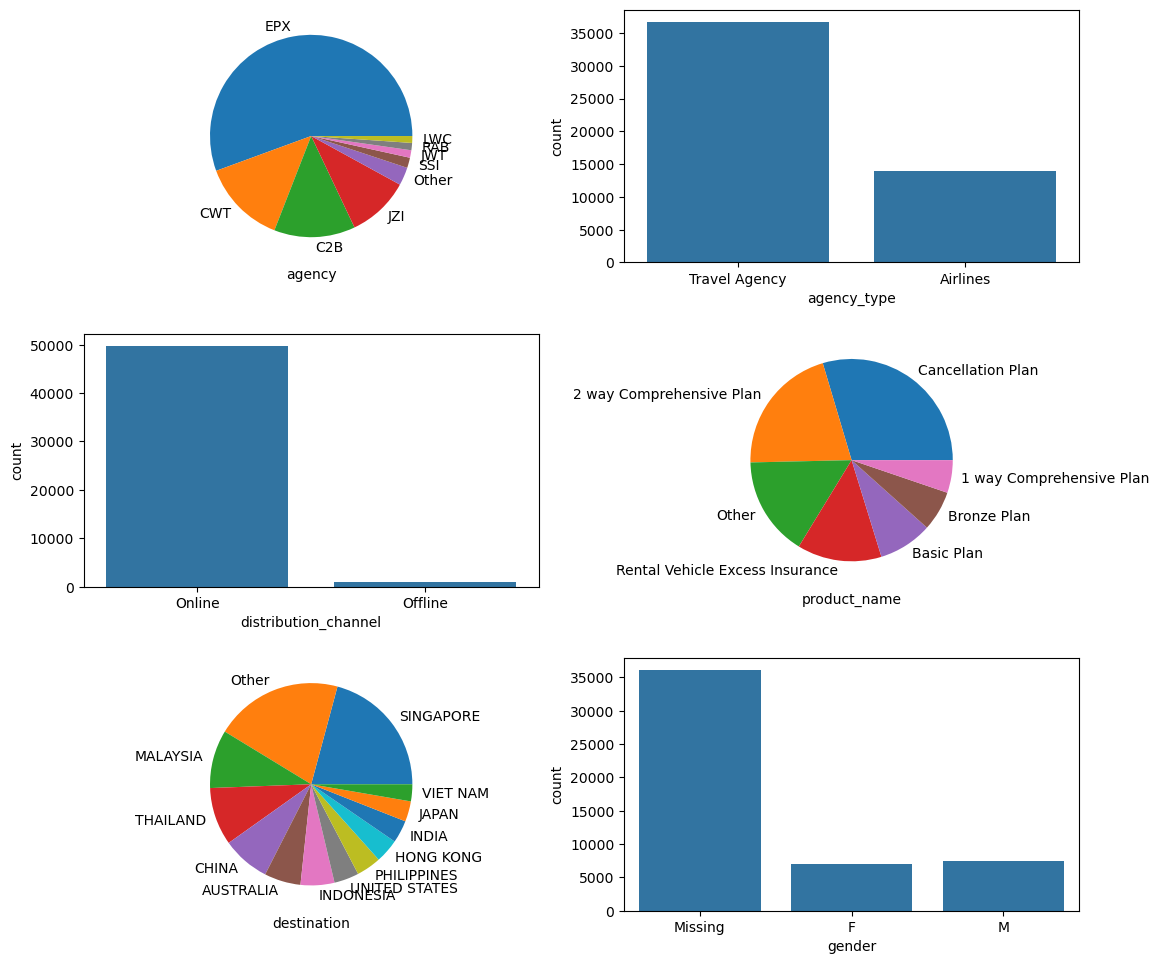

In [8]:
plot_categorical(X_train)

Let's do the same analysis, but considering only 'Yes'-claims.

In [9]:
Xy_train = pd.concat([X_train, y_train], axis=1)
min_train = Xy_train.loc[Xy_train['claim']]

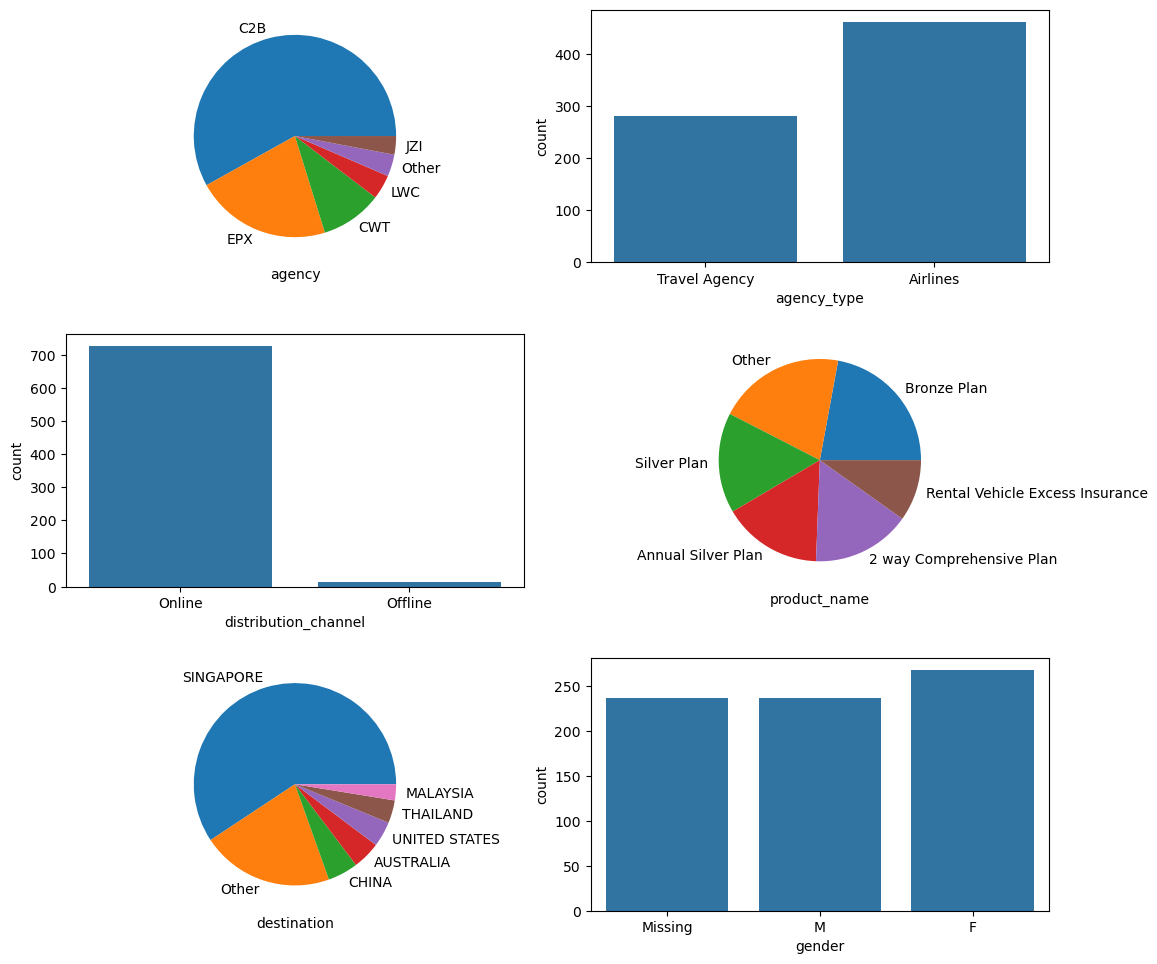

In [10]:
plot_categorical(min_train)

Here we see that the most popular destination is SINGAPORE, and there are only three agencies sharing the most of claims. Also gender has fewer 'Missing' values, and there are specific 'silver' and 'bronze' plans with claims. Also claims are in large from airlines.

To represent these facts, separate features are created, like ```is_singapore```, ```is_silver_bronze_plan``` and ```is_high_claim_agency```.

#### Continuous Features

- duration
- net_sales
- commision
- age

First three are scaled with StandardScaler. Outlier age of ~120 years is replaced by mean age (excluding the outliers). Negative durations (very few of them are present, perhaps DQ-issue) are replaced with 0.

For some reason, there are a lot of claims at age of 36.

In [11]:
X_train_upd = pd.DataFrame(X_train)

mean_age = X_train_upd.loc[X_train_upd['age'] < 100]['age'].mean()
X_train_upd['age'] = X_train_upd['age'].astype(np.float64)

X_train_upd.loc[:, 'age'] = np.where(
    X_train_upd['age'] >= 100, mean_age, X_train_upd['age']
)


X_train_upd['duration'] = np.where(
    X_train_upd['duration'] < 0, 0, X_train_upd['duration']
)

X_train_upd[
    ['duration_std', 'net_sales_std', 'commision_std']
] = StandardScaler().fit_transform(
    pd.DataFrame(X_train_upd[['duration', 'net_sales', 'commision']])
)

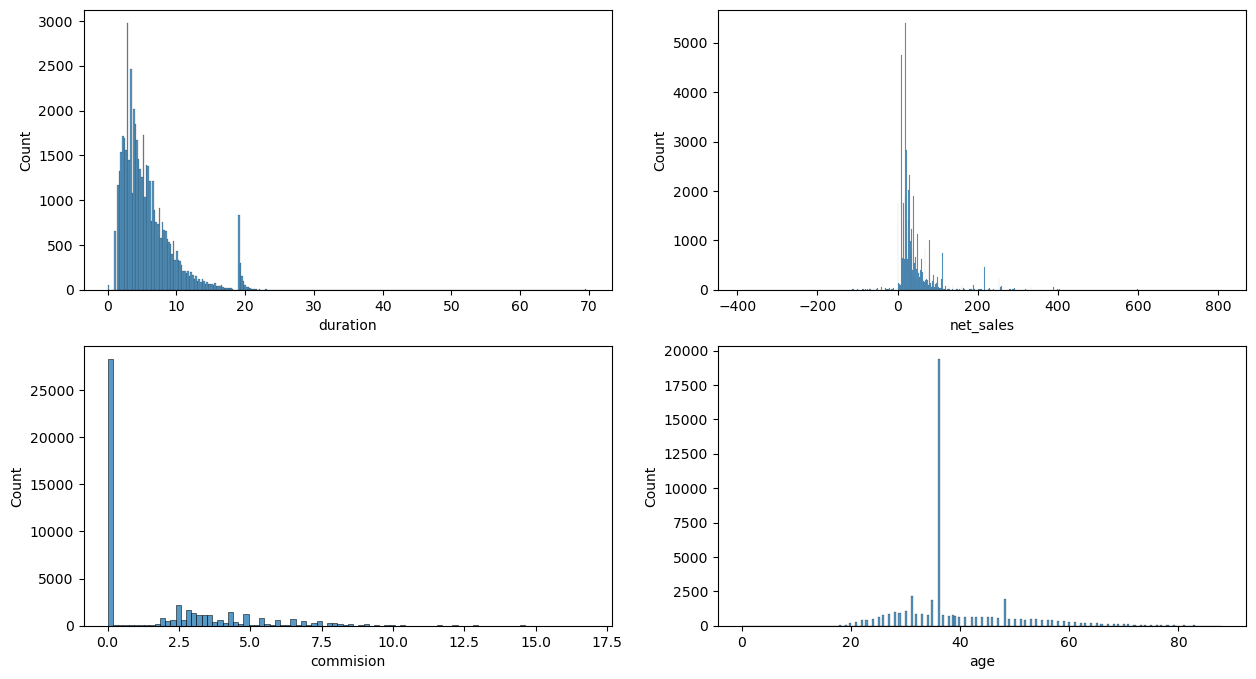

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axs_flat = axs.flat

sns.histplot(
    X_train_upd['duration'] ** 0.5, ax=axs_flat[0]
)  # sqrt-d for better demonstration and in kedro part
sns.histplot(
    X_train_upd['net_sales'], ax=axs_flat[1]
)  # sqrt-d for better demonstration
sns.histplot(X_train_upd['commision'] ** 0.5, ax=axs_flat[2])
sns.histplot(X_train_upd['age'], ax=axs_flat[3])

plt.show()

Plot the same for minority class.

In [13]:
Xy_train_upd = pd.concat([X_train_upd, y_train], axis=1)
min_train_upd = Xy_train_upd.loc[Xy_train_upd['claim']]

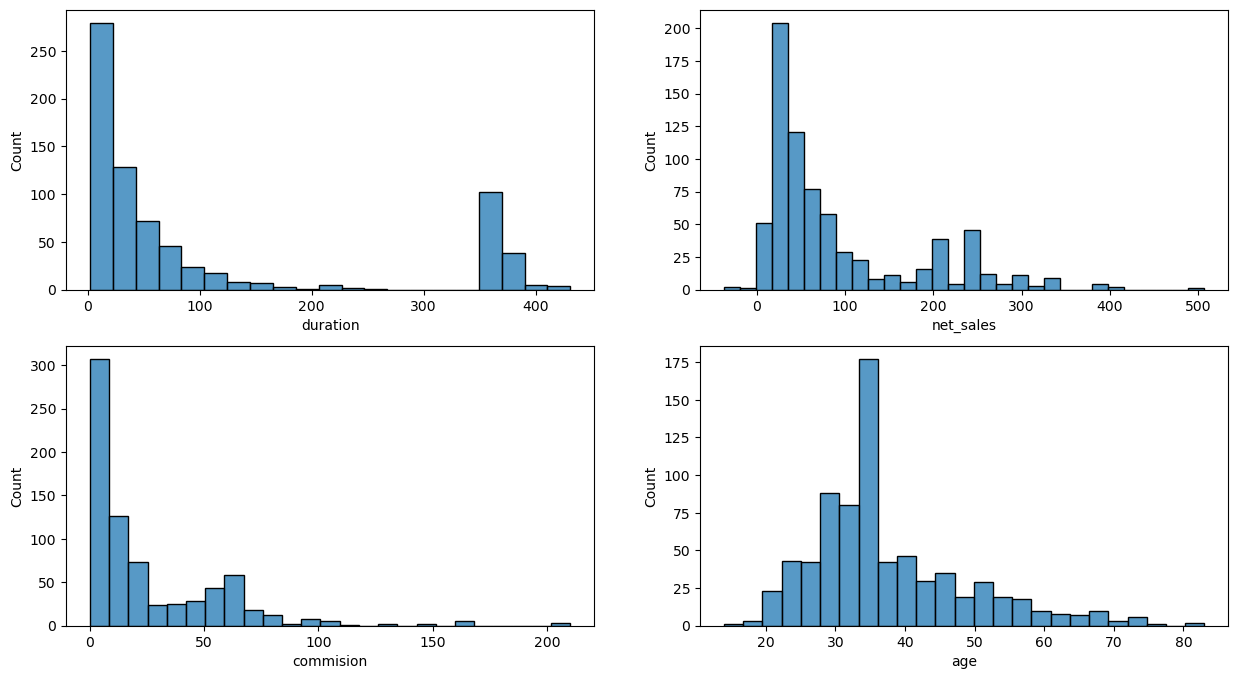

In [14]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axs_flat = axs.flat

sns.histplot(
    min_train_upd['duration'], ax=axs_flat[0]
)  # sqrt-d for better demonstration and in kedro part
sns.histplot(
    min_train_upd['net_sales'], ax=axs_flat[1]
)  # sqrt-d for better demonstration
sns.histplot(min_train_upd['commision'], ax=axs_flat[2])
sns.histplot(min_train_upd['age'], ax=axs_flat[3])

plt.show()

Positive claims have larger share of long durations, therefore let's create new feature ```is_long_duration``` for durations $>300$.

Finally, perform encoding for calculation correlations (in kedro it is done in the pipeline).

In [15]:
oh_cols = catalog.load('params:travel_insurance.encoding.one_hot_cols')

X_train_upd_c = pd.get_dummies(X_train_upd, columns=oh_cols)

catboost_cols = catalog.load('params:travel_insurance.encoding.catboost.cols')

CBE_encoder = CatBoostEncoder(cols=catboost_cols)
X_train_upd_c = CBE_encoder.fit_transform(X_train_upd_c, y_train)
X_train_upd_c.head(10)

[01/12/25 23:26:39] INFO     Loading data from params:travel_insurance.encoding.one_hot_cols    ]8;id=654239;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=116054;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

                    INFO     Loading data from params:travel_insurance.encoding.catboost.cols   ]8;id=887360;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=528112;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

,agency,product_name,duration,destination,net_sales,commision,age,duration_std,net_sales_std,commision_std,agency_type_Airlines,agency_type_Travel Agency,distribution_channel_Offline,distribution_channel_Online,gender_F,gender_M,gender_Missing
0,0.014647,0.014647,18,0.014647,13.0,0.00,36.0,-0.313900,-0.566039,-0.493569,False,True,False,True,False,False,True
1,0.007323,0.007323,101,0.014647,20.0,0.00,30.0,0.526626,-0.422262,-0.493569,False,True,False,True,False,False,True
2,0.004882,0.014647,25,0.014647,66.0,0.00,36.0,-0.243012,0.522560,-0.493569,False,True,False,True,False,False,True
3,0.003662,0.007323,50,0.014647,44.0,0.00,36.0,0.010159,0.070689,-0.493569,False,True,False,True,False,False,True
4,0.014647,0.014647,21,0.014647,33.5,8.38,22.0,-0.283519,-0.144977,-0.071216,True,False,False,True,True,False,False
5,0.014647,0.014647,6,0.014647,15.0,6.00,47.0,-0.435421,-0.524960,-0.191168,True,False,False,True,False,True,False
6,0.002929,0.004882,103,0.007323,20.0,0.00,30.0,0.546880,-0.422262,-0.493569,False,True,False,True,False,False,True
7,0.014647,0.014647,8,0.014647,18.0,6.30,32.0,-0.415168,-0.463341,-0.176048,True,False,False,True,True,False,False
8,0.014647,0.007323,128,0.014647,109.0,41.42,48.0,0.800051,1.405763,1.594004,False,True,False,True,False,True,False
9,0.007323,0.007323,17,0.007323,20.0,5.00,21.0,-0.324026,-0.422262,-0.241569,True,False,False,True,True,False,False


#### Correlations

Interestingly, missing gender has high correlation with ```agency_type=Travel Agency```, while for Airlines there is a positive correlation with genders. Maybe, one is not obliged to fill in their gender?

Also, there is some correlation between destination and agency/product_name. It seems that some products are only relevant for Travel Agencies, while others are only for Airlines, which is expected, I suppose.

Commision is correlated with net sales.

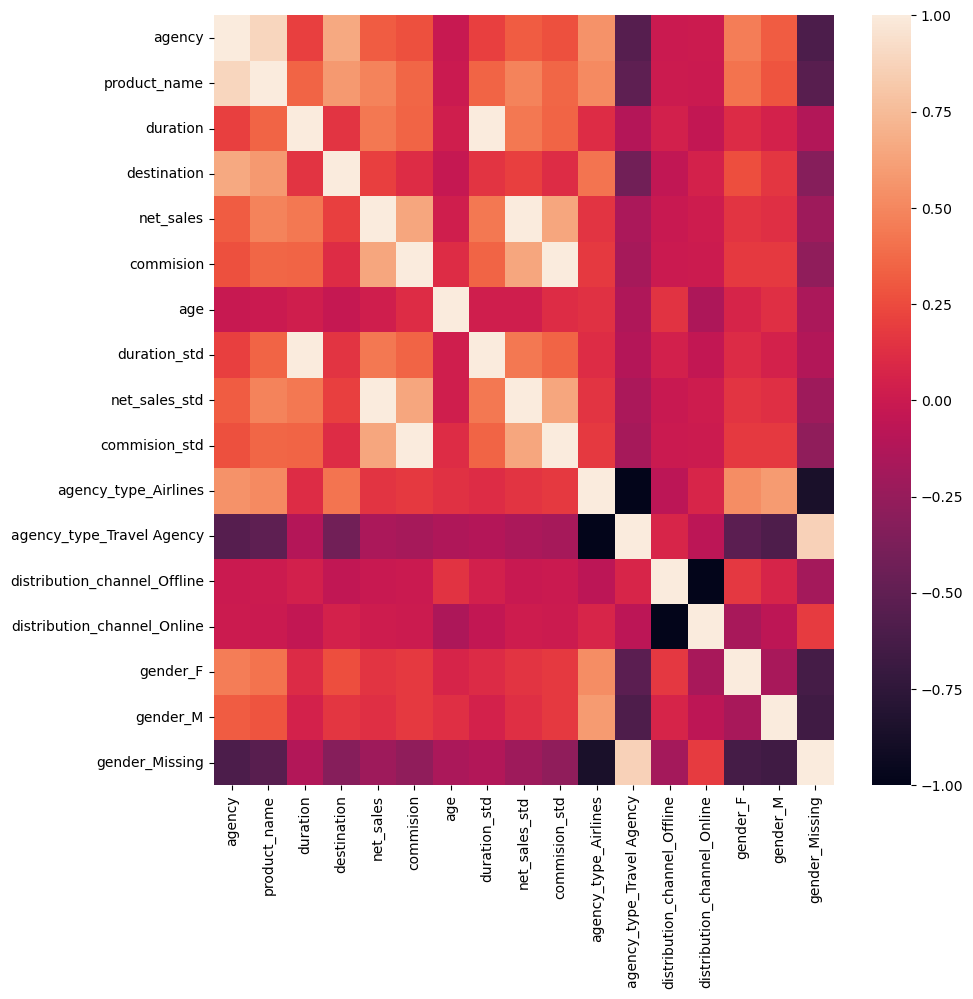

In [16]:
plt.figure(figsize=(10, 10))
corr_ax = sns.heatmap(X_train_upd_c.corr())

## Modelling

### Performance Metric Choice

As the performance metric, **PR AUC** (or ```average_precision``` in sklearn) is chosen to try to balance recall and precision. Still, precision results are underwhelming because of imbalance, while achieving higher values of recall.

From the business perspective, on one hand, it makes sense to improve recall of the model so that when the claim is indeed real, we would not miss it and pay the money. On the other hand, improving recall too much leads to making precision even worse, and we will recognize no-claim situations as claims, which may lead to high costs. What balance to choose depends on the business side.

### Models

In [17]:
best_models_stats = {}

#### Logistic Regression

- Baseline model.
- Special LogisticRegressionCV was applied to tune the regularization parameters for three cases: L1, L2 and elasticnet.
- Classes weights are 'balanced': ```n_samples / (n_classes * np.bincount(y))```

In [18]:
logitX_train, logitY_train = catalog.load('TI_train_feature'), catalog.load(
    'TI_y_train_feature'
)
logitY_train = pd.DataFrame(logitY_train).T.iloc[0]
logitX_test, logitY_test = catalog.load('TI_test_feature'), catalog.load(
    'TI_y_test_feature'
)
logitY_test = pd.DataFrame(logitY_test).T.iloc[0]

logit_trained = catalog.load('logit_trained')
logit_grand_best = logit_trained['grand_best_model']
best_estimators = logit_trained['best_models']

[01/12/25 23:26:40] INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=205679;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=789376;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/12/25 23:26:41] INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=68476;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=833851;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=990531;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=623073;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=682192;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=534005;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from logit_trained (PickleDataset)...                 ]8;id=503657;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=258123;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [19]:
best_scores = []

for b_est_idx, (best_est_name, best_est) in enumerate(best_estimators):
    y_train_pred = best_est.predict(logitX_train)
    y_train_proba = best_est.predict_proba(logitX_train)[:, 1]

    y_test_pred = best_est.predict(logitX_test)
    y_test_proba = best_est.predict_proba(logitX_test)[:, 1]

    f1_train = f1_score(logitY_train, y_train_pred)
    pr_train = precision_score(logitY_train, y_train_pred)
    recall_train = recall_score(logitY_train, y_train_pred)
    avg_pr_train = average_precision_score(logitY_train, y_train_proba)

    xgb_f1_test = f1_score(logitY_test, y_test_pred)
    xgb_pr_test = precision_score(logitY_test, y_test_pred)
    xgb_recall_test = recall_score(logitY_test, y_test_pred)
    xgb_pr_score = average_precision_score(logitY_test, y_test_proba)

    best_scores.append([])

    best_scores[b_est_idx] += [
        best_est_name,
        f1_train,
        pr_train,
        recall_train,
        avg_pr_train,
        xgb_f1_test,
        xgb_pr_test,
        xgb_recall_test,
        xgb_pr_score,
    ]


logit_best_scores_df = pd.DataFrame(
    best_scores,
    columns=[
        'name',
        'f1_train',
        'precision_train',
        'recall_train',
        'avg_precision_train',
        'f1_test',
        'precision_test',
        'recall_test',
        'avg_precision_test',
    ],
)


logit_best_scores_df

,name,f1_train,precision_train,recall_train,avg_precision_train,f1_test,precision_test,recall_test,avg_precision_test
0,L1,0.088356,0.047225,0.684636,0.072448,0.086505,0.046211,0.675676,0.084151
1,L2,0.087983,0.047018,0.683288,0.072508,0.086326,0.046108,0.675676,0.083991
2,elasticnet,0.087937,0.046992,0.683288,0.072476,0.086356,0.046125,0.675676,0.084006


In [20]:
print(f'L2 C={logit_grand_best[1].C_[0]}')

logit_pr_score = logit_best_scores_df.iloc[1]['avg_precision_test']
print(f'Test pr score: {logit_pr_score}')

L2 C=2.0
Test pr score: 0.08399068613900777


In [21]:
best_models_stats['logit'] = logit_best_scores_df.iloc[1][
    ['precision_test', 'recall_test', 'f1_test', 'avg_precision_test']
].values

### xgboost

- Applied was ```XGBClassifier``` with ```objective='binary:logistic'```
- Cross-validation: 10000 runs of ```RandomizedSearchCV``` across the space of parameters
- CV considered ```n_estimators```, ```max_depth```, ```learning_rate```, and other parameters
- Classifier was retrained on best parameters with early stopping.
- Classes are balanced.

In [22]:
xgbX_train, xgbY_train = catalog.load('TI_train_feature'), catalog.load(
    'TI_y_train_feature'
)
xgbX_test, xgbY_test = catalog.load('TI_test_feature'), catalog.load(
    'TI_y_test_feature'
)

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=814918;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=408931;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=3638;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=903042;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=55233;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=346731;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/12/25 23:26:42] INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=707732;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=396133;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [23]:
xgboost_trained = catalog.load('xgboost_trained')
xgboost_best_model = xgboost_trained['final_model']
xgboost_best_params = xgboost_trained['best_params']

xgboost_best_params

                    INFO     Loading data from xgboost_trained (PickleDataset)...               ]8;id=331787;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=630730;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\


{
    'learning_rate': 0.06988720128042956,
    'max_delta_step': 6.296916239722769,
    'max_depth': 6,
    'max_leaves': 5,
    'n_estimators': 147,
    'reg_alpha': 2.146961603256851,
    'reg_lambda': 2.0940747504698893,
    'scale_pos_weight': 4.027740693899661,
    'subsample': 0.20761648665913945
}

In [24]:
xgb_y_pred = xgboost_best_model.predict(xgbX_test)
xgb_y_proba = xgboost_best_model.predict_proba(xgbX_test)

In [25]:
xgb_f1_test = f1_score(xgbY_test, xgb_y_pred)
xgb_pr_test = precision_score(xgbY_test, xgb_y_pred)
xgb_recall_test = recall_score(xgbY_test, xgb_y_pred)
xgb_pr_score = average_precision_score(xgbY_test, xgb_y_proba[:, 1])

print(
    f'precision={xgb_pr_test}, recall={xgb_recall_test}, F1={xgb_f1_test}, avg.pr.={xgb_pr_score}.'
)

                    WARNING  c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\sklearn\metrics ]8;id=682562;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py\warnings.py]8;;\:]8;id=583670;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\warnings.py#112\112]8;;\
                             \_classification.py:1531: UndefinedMetricWarning: Precision is                        
                             ill-defined and being set to 0.0 due to no predicted samples. Use                     
                             `zero_division` parameter to control this behavior.                                   
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

precision=0.0, recall=0.0, F1=0.0, avg.pr.=0.08560482917994731.


In [26]:
best_models_stats['xgb'] = np.array(
    [xgb_pr_test, xgb_recall_test, xgb_f1_test, xgb_pr_score]
)

### lgbm

- Applied was ```LGBMClassifier``` with ```objective='binary'```
- Cross-validation: 10000 runs of ```RandomizedSearchCV``` across the space of parameters
- CV considered ```n_estimators```, ```learning_rate```, ```reg_alpha```,  ```reg_lambda```,  and other parameters
- Classifier was retrained on best parameters with early stopping.
- Classes are balanced.

In [27]:
lgbmX_train, lgbmY_train = catalog.load('TI_train_feature'), catalog.load(
    'TI_y_train_feature'
)
lgbmX_test, lgbmY_test = catalog.load('TI_test_feature'), catalog.load(
    'TI_y_test_feature'
)

lgbmX_train.columns = lgbmX_train.columns.str.replace(' ', '')
lgbmX_test.columns = lgbmX_test.columns.str.replace(' ', '')

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=779267;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=206656;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/12/25 23:26:43] INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=351573;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=322371;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=335138;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=853640;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=966922;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=587008;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [28]:
lgbm_trained = catalog.load('lgbm_trained')
lgbm_best_model = lgbm_trained['final_model']
lgbm_best_params = lgbm_trained['best_params']

lgbm_best_params

                    INFO     Loading data from lgbm_trained (PickleDataset)...                  ]8;id=173849;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=309273;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\


{
    'learning_rate': 0.3527730049936677,
    'min_child_samples': 87,
    'n_estimators': 20,
    'num_leaves': 11,
    'reg_alpha': 1.4218484007835983,
    'reg_lambda': 0.48300143578789534
}

In [29]:
lgbm_y_pred = lgbm_best_model.predict(lgbmX_test)
lgbm_y_proba = lgbm_best_model.predict_proba(lgbmX_test)

In [30]:
lgbm_f1_test = f1_score(lgbmY_test, lgbm_y_pred)
lgbm_pr_test = precision_score(lgbmY_test, lgbm_y_pred)
lgbm_recall_test = recall_score(lgbmY_test, lgbm_y_pred)
lgbm_pr_score = average_precision_score(lgbmY_test, lgbm_y_proba[:, 1])

print(
    f'precision={lgbm_pr_test}, recall={lgbm_recall_test}, F1={lgbm_f1_test}, avg.pr.={lgbm_pr_score}.'
)

precision=0.04399008674101611, recall=0.7675675675675676, F1=0.08321125109874011, avg.pr.=0.08737855163022473.


In [31]:
best_models_stats['lgbm'] = np.array(
    [lgbm_pr_test, lgbm_recall_test, lgbm_f1_test, lgbm_pr_score]
)

#### Neural Network

- Neural network with two inner layers.
- After each inner layer there is a dropout layer.
- Share of dropout, as well as amount of outputs for inner layers, is decided by CV.

In [32]:
kX_train, kY_train = catalog.load('TI_train_feature'), catalog.load(
    'TI_y_train_feature'
)
kX_test, kY_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

kX_train, kX_test = (
    kX_train.astype(np.float64).values,
    kX_test.astype(np.float64).values,
)
kY_train, kY_test = kY_train.values, kY_test.values

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=386202;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=467722;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=71685;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=758440;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=405009;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=864384;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=538713;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=689197;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [33]:
nn_trained = catalog.load('nn_trained')
nn_best_model = nn_trained['best_model']
nn_best_params = nn_trained['best_params']
nn_params_evals = nn_trained['params_evals']

nn_best_evals = nn_params_evals[np.argmax([v[0] for v in nn_params_evals], axis=0)]

nn_best_model.summary()

                    INFO     Loading data from nn_trained (PickleDataset)...                    ]8;id=678034;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=335600;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

Model: "sequential_225"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_900 (Dense)               │ (None, 50)             │         1,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_901 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_450 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_902 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_451 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_903 (Dense)               │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,205 (75.02 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,804 (50.02 KB)

In [34]:
nn_best_params

{'dense_output_size': 50, 'dropout_size': 0.3}

In [35]:
nn_y_proba = nn_best_model.predict(kX_test)

nn_y_proba = nn_y_proba.T[0]
nn_y_pred = np.where(nn_y_proba > 0.5, 1, 0)

396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [36]:
nn_f1_test = f1_score(kY_test, nn_y_pred)
nn_pr_test = precision_score(kY_test, nn_y_pred)
nn_recall_test = recall_score(kY_test, nn_y_pred)
nn_pr_score = average_precision_score(kY_test, nn_y_proba)

print(
    f'precision={nn_pr_test}, recall={nn_recall_test}, F1={nn_f1_test}, avg.pr.={nn_pr_score}.'
)

precision=0.039853970185579554, recall=0.7081081081081081, F1=0.07546082949308756, avg.pr.=0.09640620980223966.


In [37]:
best_models_stats['nn'] = np.array(
    [nn_pr_test, nn_recall_test, nn_f1_test, nn_pr_score]
)

### Model Comparison

In [38]:
best_model_stats_df = pd.DataFrame(
    best_models_stats, index=['precision', 'recall', 'f1', 'avg_pr_score']
).T
best_model_stats_df.sort_values(by='avg_pr_score')

,precision,recall,f1,avg_pr_score
logit,0.046108,0.675676,0.086326,0.083991
xgb,0.0,0.0,0.0,0.085605
lgbm,0.04399,0.767568,0.083211,0.087379
nn,0.039854,0.708108,0.075461,0.096406
